In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
import sys
!{sys.executable} -m pip install pandas seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
sns.set(style="whitegrid",palette="Set2",font_scale=1.1)

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [30]:
df.dropna(inplace=True)

In [31]:
df.shape

(1332, 10)

In [32]:
df.isna().sum().sum()

np.int64(0)

In [33]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1332.0,NaN,NaN,NaN,674.474474,384.703785,1.0,341.75,674.5,1007.25,1340.0
age,1332.0,NaN,NaN,NaN,38.086336,11.112804,18.0,29.0,38.0,47.0,60.0
gender,1332,2,male,670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1332.0,NaN,NaN,NaN,30.658333,6.118967,16.0,26.2,30.35,34.725,53.1
bloodpressure,1332.0,NaN,NaN,NaN,94.189189,11.445173,80.0,86.0,92.0,99.0,140.0
diabetic,1332,2,No,695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
children,1332.0,NaN,NaN,NaN,1.09985,1.205958,0.0,0.0,1.0,2.0,5.0
smoker,1332,2,No,1058,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1332,4,southeast,442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
claim,1332.0,NaN,NaN,NaN,13325.246426,12109.620712,1121.87,4760.1575,9412.965,16781.3275,63770.43


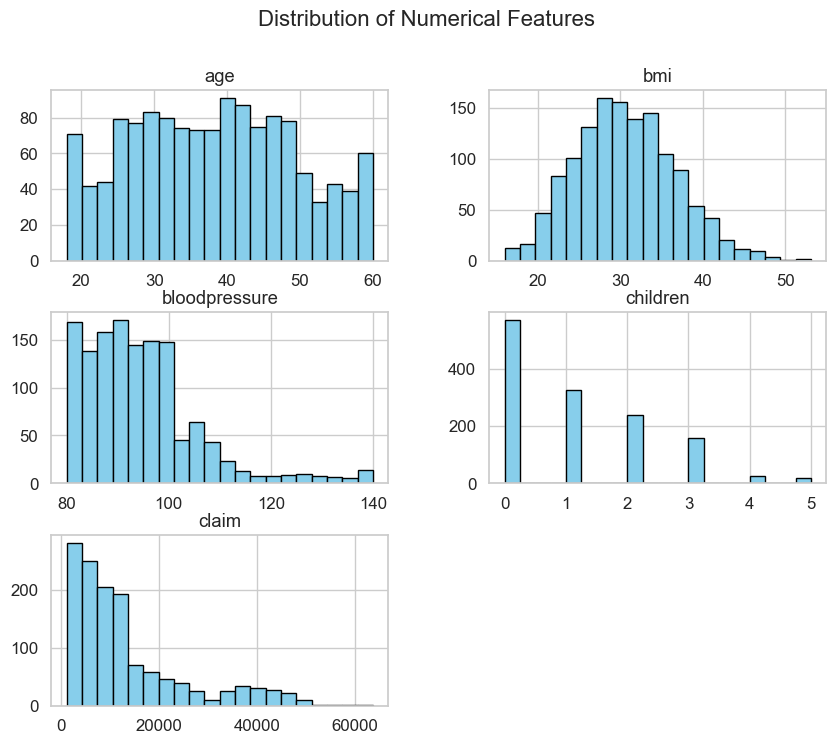

In [34]:
num_cols=['age','bmi','bloodpressure','children','claim']
df[num_cols].hist(bins=20, figsize=(10,8),color='skyblue',edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.show()

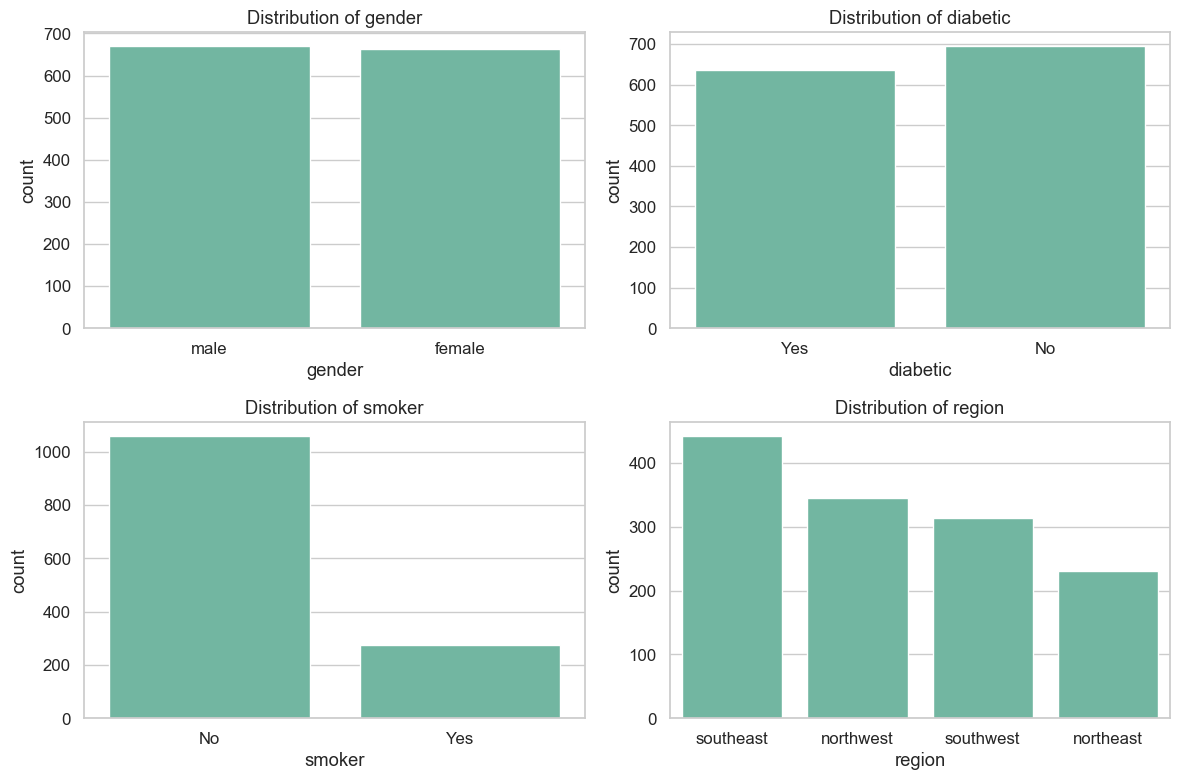

In [35]:
cat_cols=['gender','diabetic','smoker','region']
plt.figure(figsize=(12,8))
for i, col in enumerate(cat_cols,1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [36]:
df.groupby(['gender','smoker'])['claim'].mean().round(2)

gender  smoker
female  No         8762.30
        Yes       30679.00
male    No         8169.25
        Yes       33042.01
Name: claim, dtype: float64

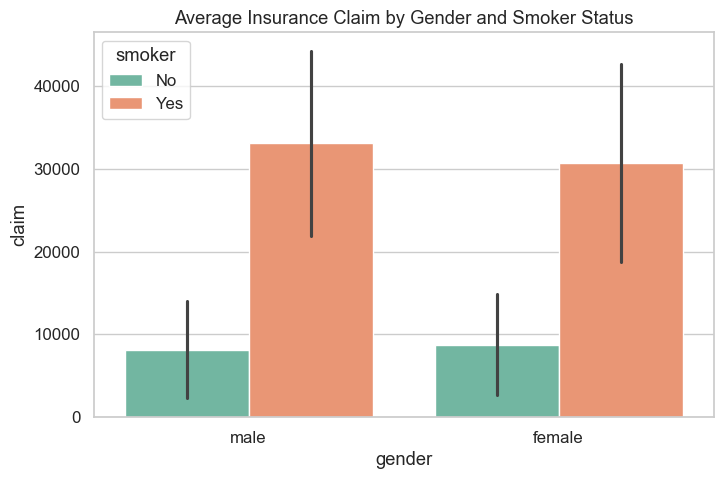

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='gender', y='claim', hue='smoker',estimator='mean', errorbar='sd')
plt.title('Average Insurance Claim by Gender and Smoker Status')
plt.show()

In [38]:
pivot_region_diabetic = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()

In [39]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.861455,16818.302231
northwest,11442.831842,12224.958000
southeast,13578.717200,12574.093226
southwest,13069.907824,12313.739167


Text(0.5, 0, 'Region')

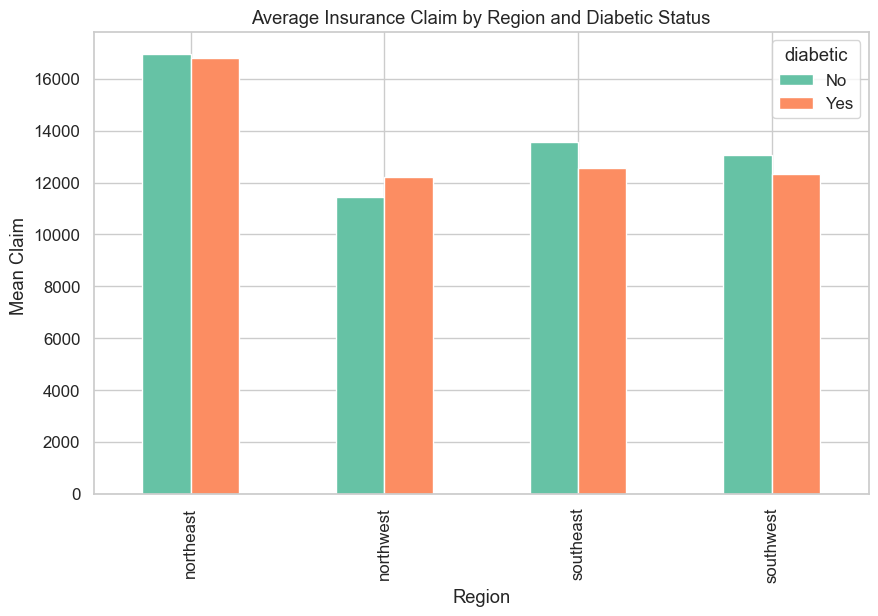

In [40]:
pivot_region_diabetic.plot(kind='bar', figsize=(10,6))
plt.title('Average Insurance Claim by Region and Diabetic Status')
plt.ylabel('Mean Claim ')
plt.xlabel('Region')

In [41]:
pivot_table=pd.pivot_table(df,values='claim', index='region', columns='smoker', aggfunc='mean')
pivot_table

smoker,No,Yes
region,,
northeast,11666.112195,29673.536269
northwest,8076.203415,30192.002759
southeast,7444.144872,34844.997253
southwest,8294.754102,32269.064138


In [42]:
pivot_table=pd.pivot_table(df,values='claim', index='children', columns='diabetic', aggfunc='mean')
pivot_table

diabetic,No,Yes
children,,
0,12967.395398,11985.289857
1,12730.455810,12732.055724
2,15567.767583,14579.360417
3,13807.612892,17091.258649
4,14106.630000,13573.352500
5,8519.043636,9205.594286


In [43]:
num_cols = ['age','bmi','bloodpressure','children','claim']
num_cols

['age', 'bmi', 'bloodpressure', 'children', 'claim']

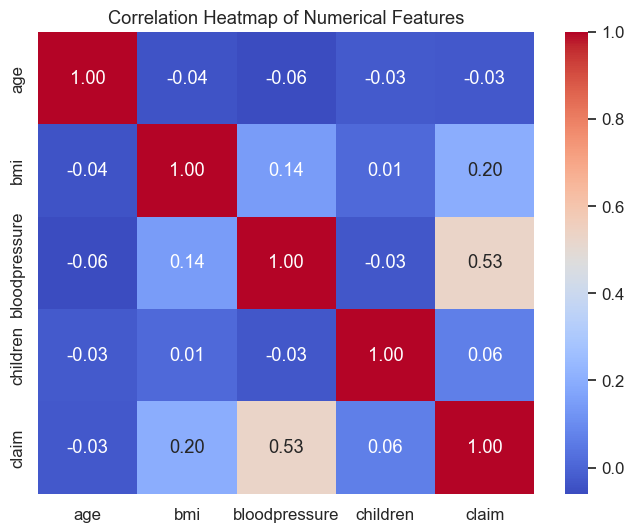

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Text(0.5, 1.0, 'Age vs Claim Amount by Smoker Status and Gender')

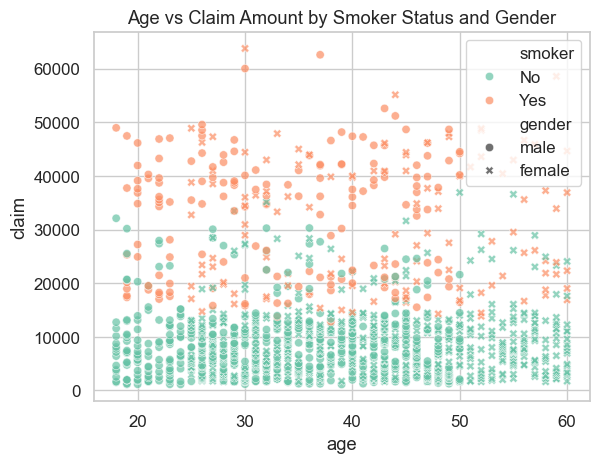

In [45]:
sns.scatterplot(data=df, x='age', y='claim', hue='smoker',style='gender',alpha=0.7)
plt.title('Age vs Claim Amount by Smoker Status and Gender')


Text(0.5, 1.0, 'Relationship between BMI and Insurance Claim Amount')

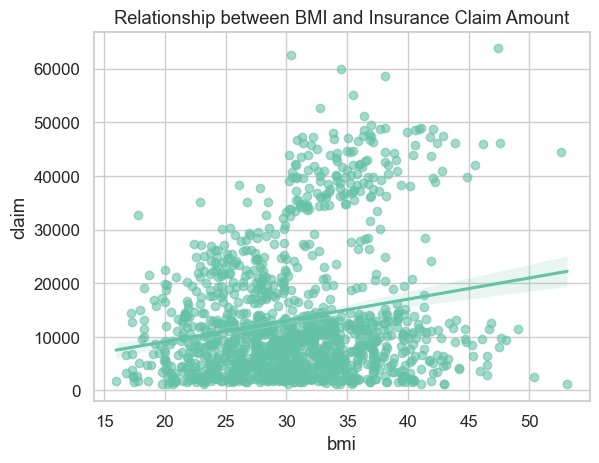

In [46]:
sns.regplot(data=df, x='bmi', y='claim', scatter_kws={'alpha':0.6})
plt.title('Relationship between BMI and Insurance Claim Amount')

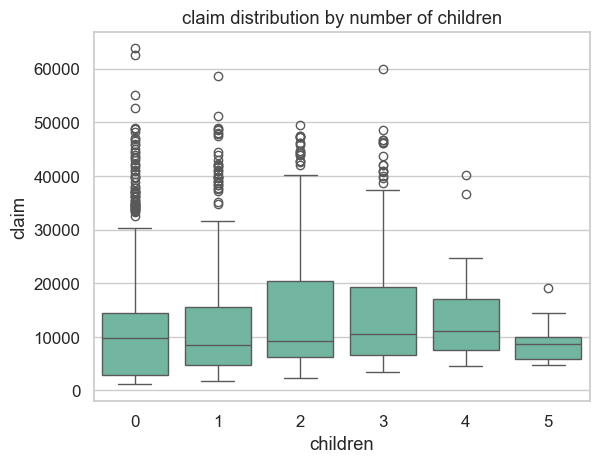

In [47]:
sns.boxplot(data=df, x='children', y='claim')
plt.title('claim distribution by number of children')
plt.show()

In [48]:
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 30, 45, 60, 100], labels=['<18', '18-30', '31-45', '46-60', '60+'])
df


,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51,18-30
7,8,19.0,male,41.1,100,No,0,No,northwest,1146.80,18-30
8,9,20.0,male,43.0,86,No,0,No,northwest,1149.40,18-30
9,10,30.0,male,53.1,97,No,0,No,northwest,1163.46,18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40,18-30
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87,31-45


In [49]:
df['age_group'].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

Text(0.5, 1.0, 'Average Insurance Claim by Age Group')

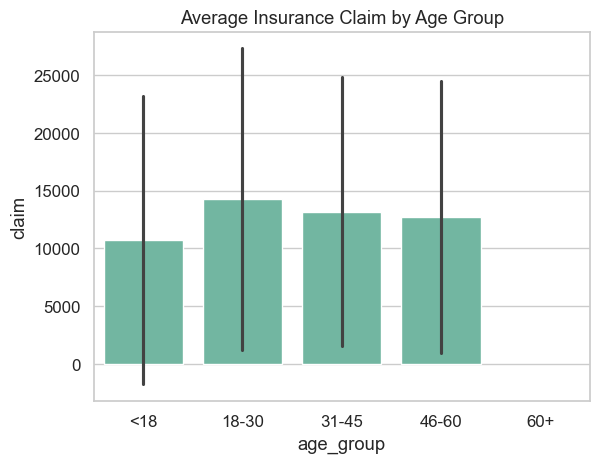

In [50]:
sns.barplot(data=df, x='age_group', y='claim', estimator='mean', errorbar='sd')
plt.title('Average Insurance Claim by Age Group')


In [51]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 24.9, 29.9, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [52]:
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

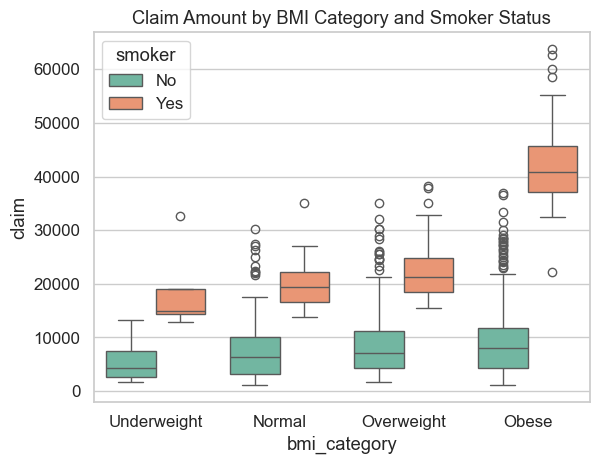

In [53]:
sns.boxplot(data=df, x='bmi_category', y='claim',hue='smoker')
plt.title('Claim Amount by BMI Category and Smoker Status')
plt.show()

In [54]:
region_status = (
    df.groupby('region')
      .agg(
          smoker_rate=('smoker', lambda x: (x == 'yes').mean() * 100),
          mean_claim=('claim', 'mean')
      )
      .reset_index()
)

In [55]:
region_status

,region,smoker_rate,mean_claim
0,northeast,0.0,16889.044719
1,northwest,0.0,11794.221855
2,southeast,0.0,13085.496833
3,southwest,0.0,12723.129841


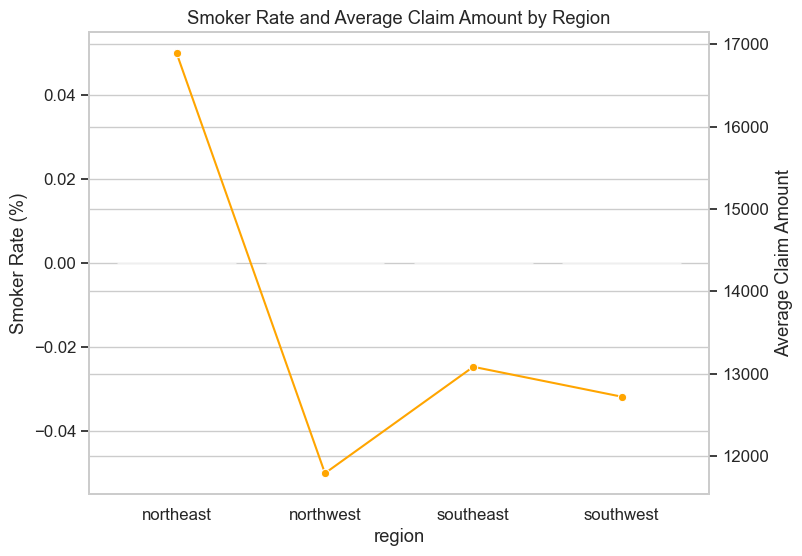

In [56]:
fig,ax1=plt.subplots(figsize=(8,6))
sns.barplot(data=region_status, x='region', y='smoker_rate', ax=ax1, alpha=0.7)
ax2=ax1.twinx()
sns.lineplot(data=region_status, x='region', y='mean_claim', ax=ax2, marker='o', color='orange')
ax1.set_ylabel('Smoker Rate (%)')
ax2.set_ylabel('Average Claim Amount')
plt.title('Smoker Rate and Average Claim Amount by Region')
plt.show()


In [57]:
import sys
print(sys.executable)

c:\Python313\python.exe


In [58]:
df=pd.read_csv('insurance.csv')


In [59]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
import joblib

In [61]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim'],
      dtype='str')

In [62]:
x=df[['age','gender','bmi','bloodpressure','diabetic','children','smoker']]
y=df['claim']

In [63]:
x

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.0,male,23.2,91,Yes,0,No
1,24.0,male,30.1,87,No,0,No
2,NaN,male,33.3,82,Yes,0,No
3,NaN,male,33.7,80,No,0,No
4,NaN,male,34.1,100,No,0,No
...,...,...,...,...,...,...,...
1335,44.0,female,35.5,88,Yes,0,Yes
1336,59.0,female,38.1,120,No,1,Yes
1337,30.0,male,34.5,91,Yes,3,Yes
1338,37.0,male,30.4,106,No,0,Yes


In [64]:
cat_cols=['gender','diabetic','smoker']
label_encoders={}

In [65]:
for col in cat_cols:
    le=LabelEncoder()
    x[col]=le.fit_transform(x[col])
    label_encoders[col]=le
    joblib.dump(le,f'label_encoder_{col}.pkl')

In [66]:
x

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.0,1,23.2,91,1,0,0
1,24.0,1,30.1,87,0,0,0
2,NaN,1,33.3,82,1,0,0
3,NaN,1,33.7,80,0,0,0
4,NaN,1,34.1,100,0,0,0
...,...,...,...,...,...,...,...
1335,44.0,0,35.5,88,1,0,1
1336,59.0,0,38.1,120,0,1,1
1337,30.0,1,34.5,91,1,3,1
1338,37.0,1,30.4,106,0,0,1


In [67]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [68]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [69]:
num_cols=['age','bmi','bloodpressure','children']
scaler=StandardScaler()
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
x_test[num_cols]=scaler.transform(x_test[num_cols])
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [70]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(1072, 7) (1072,)
(268, 7) (268,)


In [71]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score   
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor    

In [72]:
def evaluate_model(model, x_train,x_test,y_train,y_test):
    y_pred=model.predict(x_test)
    r2=r2_score(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    
    return {'R2':r2,'MAE':mae,'RMSE':rmse}

In [73]:
results={}

In [74]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # for numerical columns

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [83]:
x_train = imputer.fit_transform(x_train)

In [84]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', LinearRegression())
])

pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

In [87]:
hr=LinearRegression()
lr.fit(x_train,y_train)
results['Linear Regression']=evaluate_model(lr,x_train,x_test,y_train,y_test)
print("linear regression model trained")
best_poly_model=None
best_poly_score=-np.inf
for degree in [2,3]:
    poly=PolynomialFeatures(degree=degree)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    lr_poly=LinearRegression()
    lr_poly.fit(x_train_poly,y_train)
    score=lr_poly.score(x_test_poly,y_test)
    if score>best_poly_score:
        best_poly_score=score
        best_poly_model=(degree, poly, lr_poly, x_train_poly, x_test_poly )
degree, poly, lr_poly, x_train_poly, x_test_poly = best_poly_model
results[f'Polynomial Regression (degree={degree})'] = evaluate_model(lr_poly, x_train_poly, x_test_poly, y_train, y_test)
print("polynomial regression model trained")
rf=RandomForestRegressor()
rf_params={
    'n_estimators':[100,200],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
rf_grid=GridSearchCV(rf,rf_params,cv=3,scoring='r2',n_jobs=-1,verbose=0)
rf_grid.fit(x_train,y_train)
best_rf=rf_grid.best_estimator_
results['Random Forest']=evaluate_model(best_rf,x_train,x_test,y_train,y_test)
print("random forest model trained,best params:",rf_grid.best_params_)
svr=SVR()
svr_params={
    'kernel':['rbf','poly','linear'],
    'C':[1,10,50],
    'epsilon':[0.1,0.2,0.5],
    'degree':[2,3]
}
svr_grid=GridSearchCV(svr,svr_params,cv=3,scoring='r2',n_jobs=-1,verbose=0)
svr_grid.fit(x_train,y_train)
best_svr=svr_grid.best_estimator_
results['SVR']=evaluate_model(best_svr,x_train,x_test,y_train,y_test)
print("SVR model trained,best params:",svr_grid.best_params_)
xgb=XGBRegressor(objective='reg:squarederror',eval_metric='rmse')
xgb_params={
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5,7],
    'subsample':[0.8,1.0]
}
xgb_grid=GridSearchCV(xgb,xgb_params,cv=3,scoring='r2',n_jobs=-1,verbose=0)
xgb_grid.fit(x_train,y_train)
best_xgb=xgb_grid.best_estimator_
results['XGBoost']=evaluate_model(best_xgb,x_train,x_test,y_train,y_test)
print("XGBoost model trained,best params:",xgb_grid.best_params_)

linear regression model trained
polynomial regression model trained
random forest model trained,best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
SVR model trained,best params: {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost model trained,best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [88]:
results

{'Linear Regression': {'R2': 0.6945026857050856,
  'MAE': 4993.494696621472,
  'RMSE': np.float64(6930.291188001038)},
 'Polynomial Regression (degree=2)': {'R2': 0.7294167182437847,
  'MAE': 4643.8483106372,
  'RMSE': np.float64(6522.262356479959)},
 'Random Forest': {'R2': 0.7704872642712236,
  'MAE': 4258.012414821838,
  'RMSE': np.float64(6006.910748000351)},
 'SVR': {'R2': 0.477877506199486,
  'MAE': 6010.459994278093,
  'RMSE': np.float64(9060.12075648)},
 'XGBoost': {'R2': 0.7760772292678606,
  'MAE': 4200.154673726096,
  'RMSE': np.float64(5933.308282303513)}}

In [89]:
results_df=pd.DataFrame(results).T.sort_values(by='R2',ascending=False)
results_df

,R2,MAE,RMSE
XGBoost,0.78,4200.15,5933.31
Random Forest,0.77,4258.01,6006.91
Polynomial Regression (degree=2),0.73,4643.85,6522.26
Linear Regression,0.69,4993.49,6930.29
SVR,0.48,6010.46,9060.12


In [102]:
models={
    'Linear Regression': lr,
    'Polynomial Regression': lr_poly,
    'Random Forest': best_rf,
    'SVR': best_svr,
    'XGBoost': best_xgb
}


In [92]:
best_r2=results_df['R2'].max()
best_r2

np.float64(0.7760772292678606)

In [94]:
top_model=results_df[results_df['R2']==best_r2]
top_model

,R2,MAE,RMSE
XGBoost,0.78,4200.15,5933.31


In [99]:
best_model_name = top_model.index[0]
best_model = models[best_model_name]
best_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [103]:
joblib.dump(best_model,'best_model.pkl')
print(f'best model selected:{top_model.index[0]}')



best model selected:XGBoost


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   str    
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   str    
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   str    
 8   region         1337 non-null   str    
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 104.8 KB


In [76]:
df.shape

(1340, 10)

In [77]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [78]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns